### <font color=skyblue>探索分群資料以主成分作為特徵資料的可能性</font>

目的：探索以主成分資料替代原始資料做為分群依據的可能性，藉此降低資料的維度，以減少計算量，甚至具有更好的分群效果。

步驟：
1. 觀察資料並進行必要的前處理，譬如：
    - 將變數資料與群組資料分離
    - 進行標準化
    - 觀察變數間的相關性
1. 執行 PCA 計算，並觀察前幾個主成分與群組的關係

<font color=yellow>資料讀取、觀察與分離</font>

In [2]:
# load data file from data/Wine.xlsx
import pandas as pd

df = pd.read_excel('data/Wine.xlsx')
# print the first 5 rows of the dataframe
print(df.head())
# print the shape of the dataframe
print(df.shape)

# separate the features and target variable
X = df.drop('Customer_Segment', axis=1)
y = df['Customer_Segment']
# print the first 5 rows of the features
X.head()

# feature names
columns = X.columns


   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  Customer_Segment  
0   3.92     1065                 1  
1   3.40     105

<font color=yellow>資料標準化與繪製盒鬚圖 Boxplot</font>

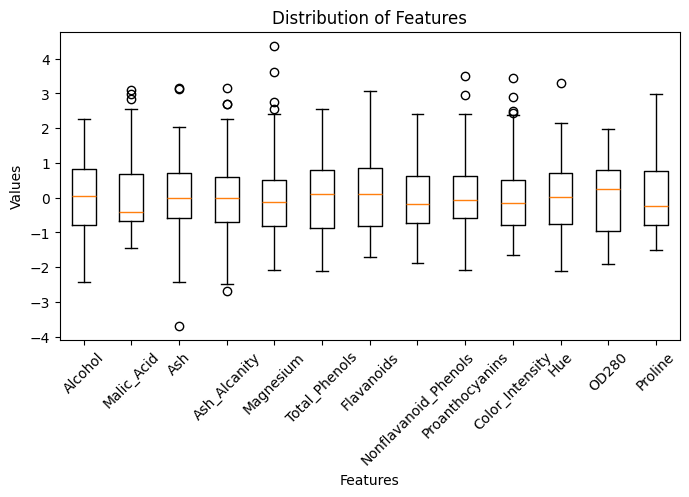

In [5]:
# standardize the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# draw the boxplot of the features      
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.boxplot(X_scaled)
# show x-axis labels as column names and rotate them 45 degrees
plt.xticks(range(1, len(columns) + 1), columns, rotation=45)
plt.xlabel('Features')
plt.ylabel('Values')
plt.title('Distribution of Features')
plt.show()

<font color=yellow>主成分分析 PCA 並繪製主成分之散佈圖</font>

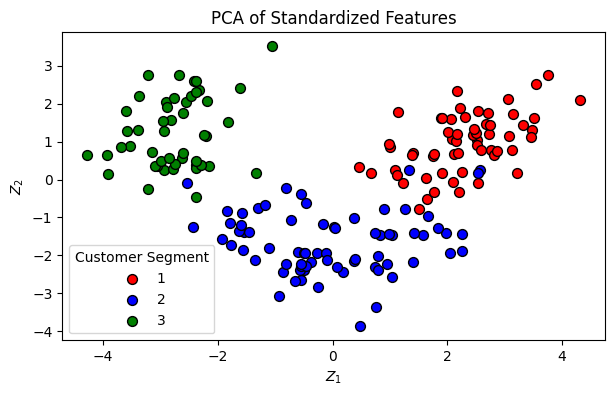

In [ ]:
# Do PCA on the standardized features
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# draw the scatter plot of the first two principal components with 
# different colors for each customer segment and legend
plt.figure(figsize=(7, 4))
for i, (label, color) in enumerate(zip(np.unique(y), ['red', 'blue', 'green'])):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], c=color, label=label, edgecolor='k', s=50)

plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.title('PCA of Standardized Features')
plt.legend(title='Customer Segment')
plt.show()


從散佈圖中可以觀察到，主成分 1($Z_1$) 與主成分 2($Z_2$) 的分布情況），並且可以看到不同群組的資料點在這兩個主成分上的分布差異。這有助於我們判斷<u>是否可以使用主成分作為特徵資料來進行分群分析</u>。